# Seattle Building Energy — Exploratory Data Analysis

**Milestone M2.** This notebook exists to make two M3 decisions safely:

1. **Target** — confirm `is_high_emitter` (GHG intensity above the median for the
   same property type in the same year) is well-defined and roughly balanced.
2. **Feature set** — pick the model inputs, decide how to handle
   `energy_star_score` nulls, and settle an exclusion rule for the emissions
   intensity outliers noted during M1 ingestion.

Data was loaded by `ingest/run.py` (M1) into `analytics.db` — 38,309
building-years, 3,871 buildings, 2015–2025. Read here through the project's
read-only engine.

> Charts are Plotly. Each cell shows the interactive figure (when you run this)
> **and** a static PNG, because GitHub strips interactive Plotly from committed
> notebooks. Run top-to-bottom; there is no hidden state.

Bootstrap: this notebook lives in `notebooks/`, so put the repo root on the path and point the project config at the repo's `analytics.db` before importing anything that reads it.

In [1]:
import os
import sys
from pathlib import Path

_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_ROOT))
os.environ.setdefault("SQLITE_PATH", str(_ROOT / "analytics.db"))

'C:\\Users\\carlo\\Documents\\Work\\Resume and CV\\analytics-agent\\analytics.db'

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from db.engine import ro_engine

# Static PNG outputs — visible on GitHub and keep the committed file small.
# For interactive exploration locally, set: pio.renderers.default = "notebook"
pio.renderers.default = "png"
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

TEMPLATE = "plotly_white"
ACCENT = "#b4491f"  # matches the portfolio site accent


def show(fig: go.Figure, *, height: int = 420, bottom: int = 50) -> None:
    fig.update_layout(template=TEMPLATE, height=height, margin=dict(t=60, r=20, b=bottom, l=70))
    fig.show()

## 1. Dataset shape

Confirm the M1 load and get oriented.

In [3]:
with ro_engine().connect() as conn:
    energy = pd.read_sql("SELECT * FROM energy_records", conn)
    buildings = pd.read_sql("SELECT * FROM buildings", conn)
    datasets = pd.read_sql("SELECT * FROM datasets", conn)

n_buildings = energy["ose_building_id"].nunique()
one_per = not energy.duplicated(["ose_building_id", "data_year"]).any()
print(f"energy_records : {len(energy):>7,} rows   {n_buildings:>6,} buildings")
print(f"buildings      : {len(buildings):>7,} rows")
print(f"data_year span : {energy['data_year'].min()}-{energy['data_year'].max()}")
print(f"one row per (building, year): {one_per}")
datasets.T

energy_records :  38,309 rows    3,871 buildings
buildings      :   3,871 rows
data_year span : 2015-2025
one row per (building, year): True


,0
dataset_key,seattle_energy
title,"Seattle Building Energy Benchmarking, 2015-Pre..."
description,Annual energy performance filings for Seattle ...
source_url,https://data.seattle.gov/resource/teqw-tu6e
row_count,38309
first_year,2015
last_year,2025
last_ingested_at,2026-09-07T08:22:04Z


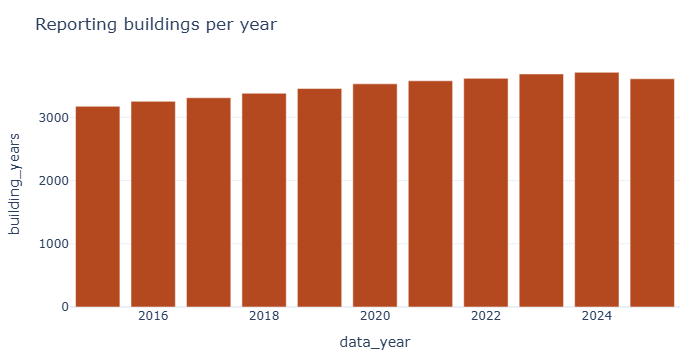

In [4]:
rows_per_year = energy.groupby("data_year").size().reset_index(name="building_years")
show(
    px.bar(
        rows_per_year,
        x="data_year",
        y="building_years",
        title="Reporting buildings per year",
        color_discrete_sequence=[ACCENT],
    ),
    height=360,
)

## 2. The target — `is_high_emitter`

Definition (architecture doc §4.4): **1** if `ghg_emissions_intensity` is above
the median for the same `primary_property_type` in the same `data_year`, else
**0**. Normalising within type + year keeps the label ~balanced and forces the
model to learn something past "big old building".

Built on rows that have a non-null intensity and are **not** demolished.

In [5]:
df = energy.merge(buildings, on="ose_building_id", how="left", validate="many_to_one")
df = df[df["demolished"].fillna(0) != 1].copy()

before = len(df)
df = df[df["ghg_emissions_intensity"].notna()].copy()
print(f"dropped {before - len(df):,} rows with null ghg_emissions_intensity; {len(df):,} remain")

_grp = df.groupby(["primary_property_type", "data_year"])["ghg_emissions_intensity"]
df["type_year_median"] = _grp.transform("median")
df["is_high_emitter"] = (df["ghg_emissions_intensity"] > df["type_year_median"]).astype(int)

print(df["is_high_emitter"].value_counts(normalize=True).round(3).to_string())

dropped 1,683 rows with null ghg_emissions_intensity; 36,297 remain
is_high_emitter
0    0.507
1    0.493


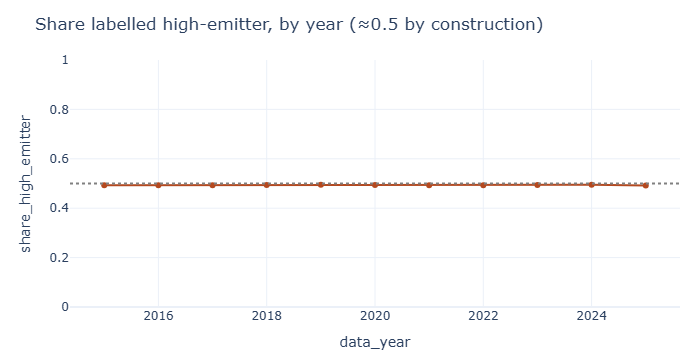

In [6]:
bal = df.groupby("data_year")["is_high_emitter"].mean().reset_index(name="share_high_emitter")
fig = px.line(
    bal,
    x="data_year",
    y="share_high_emitter",
    markers=True,
    title="Share labelled high-emitter, by year (≈0.5 by construction)",
    color_discrete_sequence=[ACCENT],
)
fig.update_yaxes(range=[0, 1])
fig.add_hline(y=0.5, line_dash="dot", line_color="grey")
show(fig, height=360)

In [7]:
# Balance holds within the larger property types too (not just in aggregate).
top_types = df["primary_property_type"].value_counts().head(12).index
by_type = (
    df[df["primary_property_type"].isin(top_types)]
    .groupby("primary_property_type")["is_high_emitter"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
    .round(3)
)
by_type

,mean,count
primary_property_type,,
Multifamily Housing,0.499,18920
Office,0.499,4715
Non-Refrigerated Warehouse,0.499,1522
K-12 School,0.498,1467
Mixed Use Property,0.496,1462
Hotel,0.496,781
Worship Facility,0.496,663
Retail Store,0.492,585
Self-Storage Facility,0.491,430


## 3. Missingness

Two questions: which columns are unusable as features, and what is the structure
of the `energy_star_score` nulls (M1 flagged them as *null by design* for
property types EPA doesn't score).

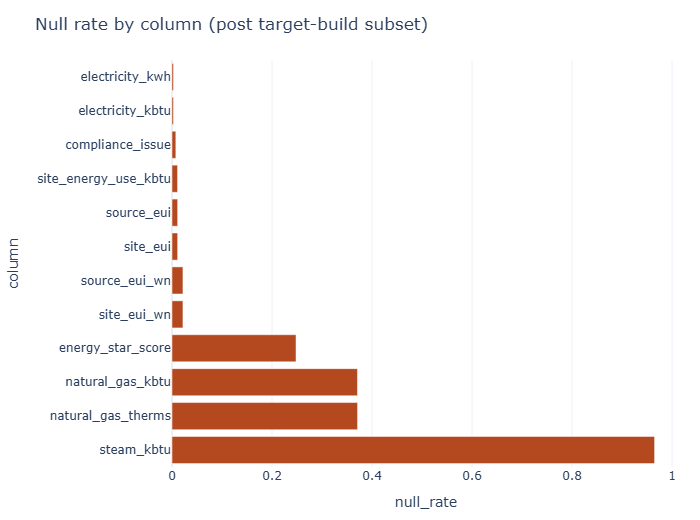

In [8]:
null_rate = df.isna().mean().sort_values(ascending=False).loc[lambda s: s > 0].reset_index()
null_rate.columns = ["column", "null_rate"]
show(
    px.bar(
        null_rate,
        x="null_rate",
        y="column",
        orientation="h",
        title="Null rate by column (post target-build subset)",
        color_discrete_sequence=[ACCENT],
    ),
    height=520,
)

In [9]:
# energy_star_score: is the null concentrated in particular property types?
es = (
    df.assign(has_score=df["energy_star_score"].notna())
    .groupby("primary_property_type")
    .agg(n=("has_score", "size"), pct_scored=("has_score", "mean"))
    .query("n >= 100")
    .sort_values("pct_scored")
)
print("least-scored property types:")
print(es.head(8).round(2).to_string())
print("\nmost-scored property types:")
print(es.tail(8).round(2).to_string())
print(f"\noverall: {df['energy_star_score'].notna().mean():.1%} of rows have a score")

least-scored property types:
                                         n  pct_scored
primary_property_type                                 
Other - Entertainment/Public Assembly  121        0.00
Other - Recreation                     238        0.00
Vehicle Repair Services                162        0.06
Other                                  392        0.07
Self-Storage Facility                  430        0.10
Data Center                            140        0.10
Laboratory                             307        0.14
Strip Mall                             111        0.15

most-scored property types:
                                           n  pct_scored
primary_property_type                                   
Multifamily Housing                    18920        0.84
Distribution Center                      398        0.85
Residence Hall/Dormitory                 130        0.85
Senior Living Community                  409        0.87
Hospital (General Medical & Surgical)    114      

**Decision:** keep `energy_star_score` as a feature **only** paired with a
`has_energy_star` indicator, and never impute 0 (a missing score is "not
eligible", not "worst possible"). Columns with very high null rates above are out.

## 4. Candidate features

From the doc: building age, `log(gfa_total)`, parking share,
`primary_property_type`, `council_district`, and the `has_energy_star` indicator.
Engineer them, then look at each distribution for skew and implausible values.

In [10]:
df["building_age"] = df["data_year"] - df["year_built"]
# year_built missing / pre-1850, or a negative age (reported before completion)
# -> age is meaningless
bad_age = df["year_built"].isna() | (df["year_built"] < 1850) | (df["building_age"] < 0)
df.loc[bad_age, "building_age"] = np.nan
print(f"{bad_age.sum():,} rows with unusable year_built/age -> building_age set NaN")

df["log_gfa_total"] = np.log10(df["gfa_total"].where(df["gfa_total"] > 0))
df["parking_share"] = (df["gfa_parking"] / df["gfa_total"]).clip(lower=0, upper=1)
df["has_energy_star"] = df["energy_star_score"].notna().astype(int)

df[["building_age", "log_gfa_total", "parking_share"]].describe().round(2)

8 rows with unusable year_built/age -> building_age set NaN


,building_age,log_gfa_total,parking_share
count,36289.00,36297.00,36297.00
mean,47.19,4.78,0.09
std,34.23,0.39,0.14
min,0.00,4.21,0.00
25%,19.00,4.47,0.00
50%,40.00,4.68,0.00
75%,67.00,5.01,0.17
max,125.00,7.18,0.87


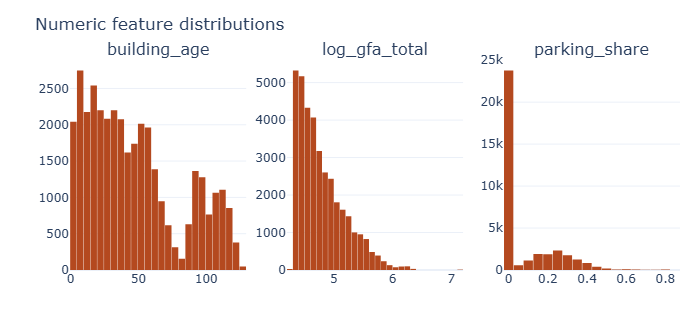

In [11]:
num_feats = ["building_age", "log_gfa_total", "parking_share"]
fig = make_subplots(rows=1, cols=3, subplot_titles=num_feats)
for i, col in enumerate(num_feats, start=1):
    fig.add_trace(go.Histogram(x=df[col], nbinsx=40, marker_color=ACCENT), row=1, col=i)
fig.update_layout(title="Numeric feature distributions", showlegend=False, bargap=0.05)
show(fig, height=320)

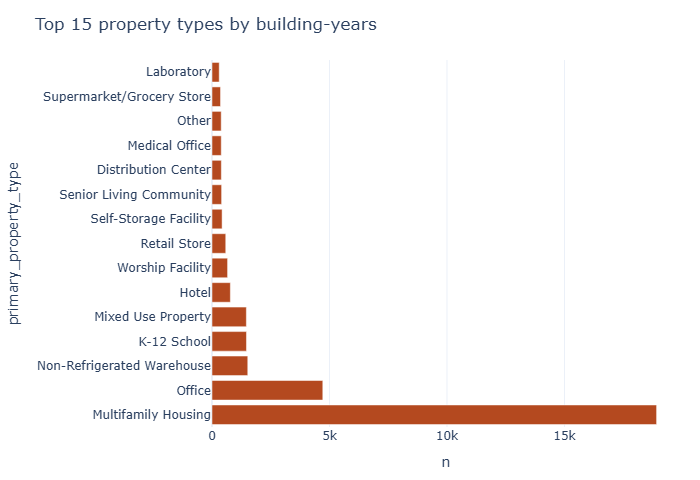

In [12]:
cat = df["primary_property_type"].value_counts().head(15).reset_index()
cat.columns = ["primary_property_type", "n"]
show(
    px.bar(
        cat,
        x="n",
        y="primary_property_type",
        orientation="h",
        title="Top 15 property types by building-years",
        color_discrete_sequence=[ACCENT],
    ),
    height=480,
)

## 5. The emissions-intensity outliers

M1's spot-check suggested a possible unit problem — *Non-Refrigerated Warehouse*
averaged ~121 kg CO₂e/sf while most types sit in single digits. First test that:
does reported `ghg_emissions_intensity` agree with a value computed straight from
`total_ghg_emissions` and floor area?

In [13]:
# reported intensity should ≈ total emissions (metric tons -> kg) / floor area
chk = df[df["gfa_total"] > 0].copy()
kg = chk["total_ghg_emissions"] * 1000
reported = chk["ghg_emissions_intensity"].replace(0, np.nan)
bldg_gfa = (chk["gfa_total"] - chk["gfa_parking"].fillna(0)).where(lambda s: s > 0)

chk["vs_total_gfa"] = kg / chk["gfa_total"] / reported
chk["vs_building_gfa"] = kg / bldg_gfa / reported

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
print("computed / reported ratio (div by total GFA):")
print(chk["vs_total_gfa"].describe(percentiles=pct).round(3).to_string())
print("\nsame div by building GFA (excl. parking) - median by parking-heavy type:")
print(
    chk[chk["gfa_parking"].fillna(0) > 0]
    .groupby("primary_property_type")[["vs_total_gfa", "vs_building_gfa"]]
    .median()
    .sort_values("vs_total_gfa")
    .dropna()
    .head(6)
    .round(3)
    .to_string()
)

computed / reported ratio (div by total GFA):
count    36297.000
mean         0.928
std          0.299
min          0.064
5%           0.610
25%          0.815
50%          0.998
75%          1.000
95%          1.089
max         13.659

same div by building GFA (excl. parking) - median by parking-heavy type:
                                     vs_total_gfa  vs_building_gfa
primary_property_type                                             
Parking                                     0.314            0.999
Worship Facility                            0.414            0.700
Supermarket/Grocery Store                   0.528            1.000
Retail Store                                0.554            1.023
Police Station                              0.555            0.946
Urgent Care/Clinic/Other Outpatient         0.624            1.074


So the column is **internally consistent** — the ratio sits at ~1.0 for the bulk
of rows (and the residual gap on parking-heavy properties is the denominator:
the City computes intensity on *building* GFA, not building + parking). M1's ~121
was a handful of genuinely extreme rows dragging an average, not a systematic
unit error. Below, the per-type medians are all sane; it's the tails that need a
flag.

In [14]:
by_type = (
    df.groupby("primary_property_type")["ghg_emissions_intensity"]
    .agg(count="count", median="median", mean="mean", p99=lambda s: s.quantile(0.99))
    .query("count >= 50")
    .sort_values("median", ascending=False)
)
by_type.head(15).round(2)

,count,median,mean,p99
primary_property_type,,,,
Hospital (General Medical & Surgical),114,6.43,6.69,12.36
Supermarket/Grocery Store,363,5.59,5.99,15.28
Restaurant,98,5.34,6.55,17.76
Laboratory,307,5.18,6.06,26.01
Other/Specialty Hospital,53,4.41,3.98,9.72
Other - Recreation,238,3.58,4.96,16.27
Residential Care Facility,56,2.78,8.59,154.70
Fitness Center/Health Club/Gym,88,2.54,5.33,41.54
Social/Meeting Hall,84,2.52,2.32,4.99


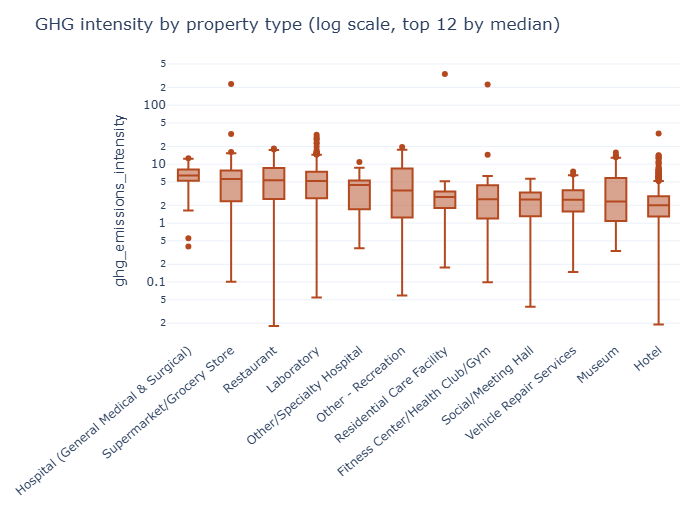

In [15]:
plot_types = list(by_type.head(12).index)
fig = px.box(
    df[df["primary_property_type"].isin(plot_types)],
    x="primary_property_type",
    y="ghg_emissions_intensity",
    log_y=True,
    category_orders={"primary_property_type": plot_types},
    title="GHG intensity by property type (log scale, top 12 by median)",
    color_discrete_sequence=[ACCENT],
)
fig.update_xaxes(tickangle=-40, title=None)
show(fig, height=520, bottom=180)

In [16]:
# Outlier flag: within property_type × year, Tukey "far out" (3×IQR beyond the
# quartiles). Robust to the skew, and per group so a whole property type is not
# nuked for having a genuinely higher baseline.
def _far_out(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        return pd.Series(False, index=s.index)
    return (s < q1 - 3 * iqr) | (s > q3 + 3 * iqr)


df["is_outlier"] = (
    df.groupby(["primary_property_type", "data_year"])["ghg_emissions_intensity"]
    .transform(_far_out)
    .astype(bool)
)
print(f"{df['is_outlier'].sum():,} rows flagged ({df['is_outlier'].mean():.2%})")
print("\nflagged rows by property type (top 10):")
print(df[df["is_outlier"]]["primary_property_type"].value_counts().head(10).to_string())

1,032 rows flagged (2.84%)

flagged rows by property type (top 10):
primary_property_type
Multifamily Housing           581
Office                        166
Multifamily LR (1-4)           33
Mixed Use Property             29
Data Center                    29
Hotel                          22
Worship Facility               22
Non-Refrigerated Warehouse     20
Parking                        18
Self-Storage Facility          17


**Decision:** add `is_outlier` as a derived column and **exclude flagged rows
from M3 training** (keep them in the database). This replaces the `outlier_flag`
the source doesn't provide.

## 6. Signal check

Is there anything to learn beyond size and age? Point-biserial correlation of each
numeric feature with `is_high_emitter`, plus the raw intensity (for the v1.1
regression stretch).

In [17]:
model_df = df[~df["is_outlier"]].copy()
corr_cols = [
    "building_age",
    "log_gfa_total",
    "parking_share",
    "has_energy_star",
    "number_of_floors",
    "gfa_total",
]
corr = (
    model_df[corr_cols + ["is_high_emitter", "ghg_emissions_intensity"]]
    .corr(numeric_only=True)[["is_high_emitter", "ghg_emissions_intensity"]]
    .drop(index=["is_high_emitter", "ghg_emissions_intensity"])
    .round(3)
)
corr

,is_high_emitter,ghg_emissions_intensity
building_age,0.039,0.053
log_gfa_total,0.130,0.018
parking_share,0.004,-0.020
has_energy_star,0.005,-0.087
number_of_floors,0.080,-0.023
gfa_total,0.050,0.017


**The linear signal is weak** — the strongest numeric correlate of
`is_high_emitter` is `log_gfa_total` at ~0.13; everything else is under 0.09.
That is partly by design: the label is normalised within `primary_property_type`
× `data_year`, so the obvious "what kind of building, how big, how old" structure
is already divided out, and what's left is within-peer-group variation.

Implication for M3: don't expect a strong classifier. A gradient-boosted model
can still pick up non-linear interactions and the `primary_property_type` effect
that a correlation misses, but **plan the model card around a modest ROC-AUC**
(≈0.60–0.68) rather than a headline number. The architecture doc anticipates
this ("weak model signal" risk, §12) and treats an honest, well-explained model
as an acceptable outcome.

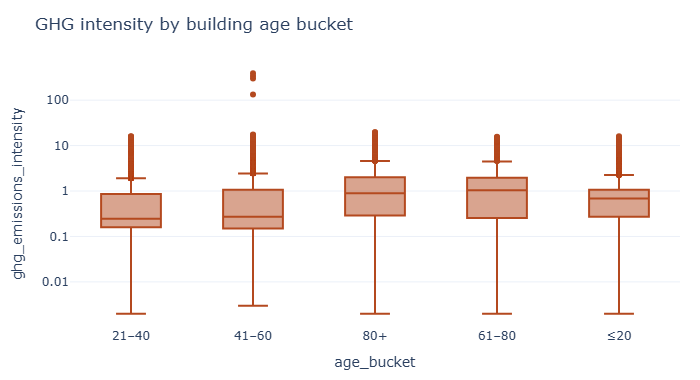

In [18]:
fig = px.box(
    model_df.assign(
        age_bucket=pd.cut(
            model_df["building_age"],
            [-1, 20, 40, 60, 80, 200],
            labels=["≤20", "21–40", "41–60", "61–80", "80+"],
        )
    ).dropna(subset=["age_bucket"]),
    x="age_bucket",
    y="ghg_emissions_intensity",
    log_y=True,
    title="GHG intensity by building age bucket",
    color_discrete_sequence=[ACCENT],
)
show(fig, height=380)

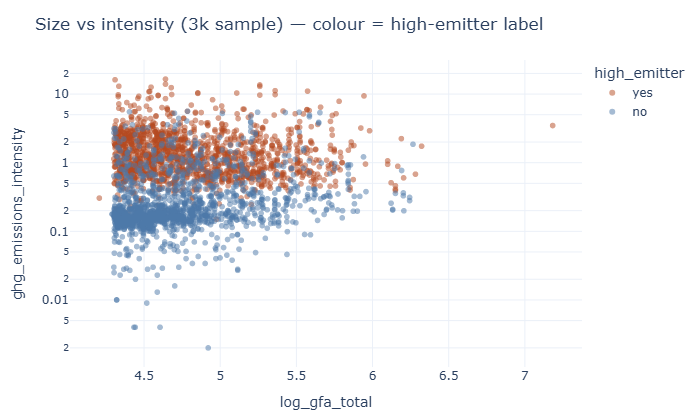

In [19]:
sample = model_df.sample(min(3000, len(model_df)), random_state=0).assign(
    high_emitter=lambda d: d["is_high_emitter"].map({0: "no", 1: "yes"})
)
fig = px.scatter(
    sample,
    x="log_gfa_total",
    y="ghg_emissions_intensity",
    log_y=True,
    color="high_emitter",
    opacity=0.5,
    title="Size vs intensity (3k sample) — colour = high-emitter label",
    color_discrete_map={"no": "#4c78a8", "yes": ACCENT},
)
show(fig, height=420)

## 7. Leakage check

The M3 split is temporal: **train** `data_year ≤ 2022`, **valid** 2023,
**test** 2024. A building appears in several years, so it will straddle the split
— check how much, and argue why it is fine here.

In [20]:
train = model_df[model_df["data_year"] <= 2022]
valid = model_df[model_df["data_year"] == 2023]
test = model_df[model_df["data_year"] == 2024]
print(f"train {len(train):>6,}   valid {len(valid):>6,}   test {len(test):>6,}")

both = set(train["ose_building_id"]) & set(test["ose_building_id"])
print(
    f"{len(both):,} buildings in both train and test "
    f"({len(both) / test['ose_building_id'].nunique():.0%} of test buildings)"
)

train 25,117   valid  3,468   test  3,428
3,295 buildings in both train and test (96% of test buildings)


That overlap is expected and **not leakage for this task**:

* The label is relative — *above this year's median for this property type* — so a
  building carries no fixed label the model could memorise.
* The real task is exactly "score this year's filings from prior years", which is
  what the split reproduces.
* None of the candidate features encode the target (no per-building historical
  intensity, no rank). If M3 adds a lagged-intensity feature, revisit this.

## 8. Findings

A few things worth showing beyond model prep — reusable for the demo gallery.

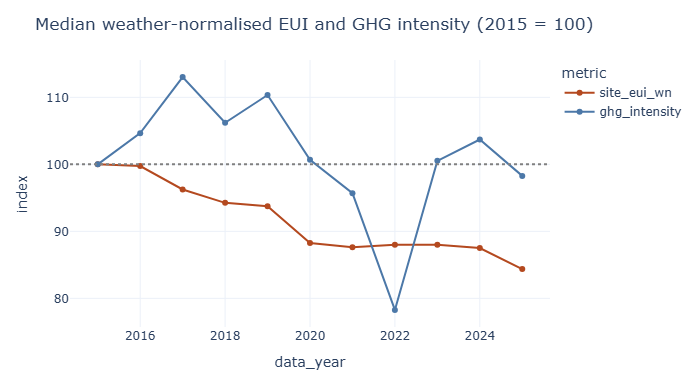

In [21]:
trend = model_df.groupby("data_year").agg(
    site_eui_wn=("site_eui_wn", "median"),
    ghg_intensity=("ghg_emissions_intensity", "median"),
)
# the two metrics live on different scales — index each to its 2015 value
indexed = (
    (trend / trend.iloc[0] * 100)
    .reset_index()
    .melt("data_year", var_name="metric", value_name="index")
)
fig = px.line(
    indexed,
    x="data_year",
    y="index",
    color="metric",
    markers=True,
    title="Median weather-normalised EUI and GHG intensity (2015 = 100)",
    color_discrete_sequence=[ACCENT, "#4c78a8"],
)
fig.add_hline(y=100, line_dash="dot", line_color="grey")
show(fig, height=380)

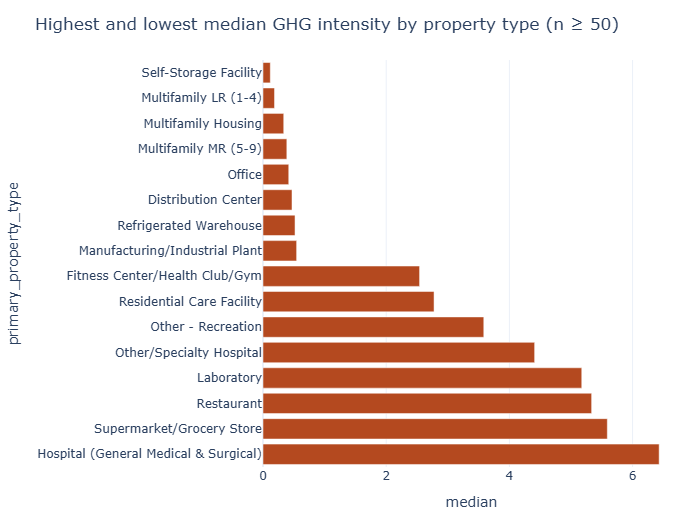

In [22]:
worst_best = pd.concat([by_type.head(8), by_type.tail(8)]).reset_index()
show(
    px.bar(
        worst_best,
        x="median",
        y="primary_property_type",
        orientation="h",
        title="Highest and lowest median GHG intensity by property type (n ≥ 50)",
        color_discrete_sequence=[ACCENT],
    ),
    height=520,
)

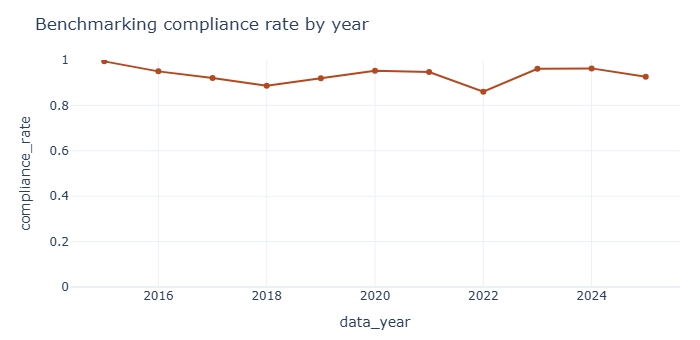

In [23]:
comp = (
    energy.assign(compliant=lambda d: d["compliance_status"].eq("Compliant"))
    .groupby("data_year")["compliant"]
    .mean()
    .reset_index(name="compliance_rate")
)
fig = px.line(
    comp,
    x="data_year",
    y="compliance_rate",
    markers=True,
    title="Benchmarking compliance rate by year",
    color_discrete_sequence=[ACCENT],
)
fig.update_yaxes(range=[0, 1])
show(fig, height=340)

## 9. Decisions for M3

| Question | Decision |
|---|---|
| **Target** | `is_high_emitter` as defined — above the `primary_property_type` × `data_year` median of `ghg_emissions_intensity`. Built on non-null intensity, non-demolished rows. |
| **Rows excluded from training** | `is_outlier` (Tukey 3×IQR within type × year) — kept in the DB, dropped from the model matrix. |
| **Features** | `building_age`, `log_gfa_total`, `parking_share`, `primary_property_type` (encode), `council_district`, `has_energy_star`; `energy_star_score` only alongside `has_energy_star`, never imputed. |
| **`year_built` hygiene** | null, `< 1850`, or negative age → `building_age` = NaN. |
| **Split** | train ≤ 2022 · valid 2023 · test 2024 (temporal; the 96% train/test building overlap is not leakage — the label is relative and no feature encodes it). |
| **Signal expectation** | Weak — all numeric feature correlations < 0.13. Target the model card at ROC-AUC ≈ 0.60–0.68; lean on `primary_property_type` + non-linear interactions. |

Next: **M3** — `model/seattle_energy/features.py` + `train.py`.